# Pretrain

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
import math
from functools import partial

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, patches, embed_dim):
        super().__init__()
        self.d_k = embed_dim
        self.patches = patches
        pe = torch.zeros(patches, self.d_k)
        div = torch.exp(torch.arange(0, self.d_k, 2).float() * -(math.log(10000.0) / self.d_k))
        position = torch.arange(0, patches).float().unsqueeze(1)
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    
    def forward(self, x):
        return x + self.pe[:, :self.patches, :].detach()

In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, h/p, w/p)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


In [4]:
class MultiheadAttention(nn.Module): # linear attention 
    def __init__(self,embed_dim,head):
        super().__init__()
        self.head = head
        self.head_dim = embed_dim // self.head 
        assert self.head * self.head_dim == embed_dim
        self.Q = nn.Linear(embed_dim,embed_dim)
        self.K = nn.Linear(embed_dim,embed_dim)
        self.V = nn.Linear(embed_dim,embed_dim)
        pass
    def feature_map(self,x):
        return F.gelu(x)
    def forward(self,x):
        # linear kernel
        B,L,E = x.size()
        q = self.Q(x).view(B,L,self.head,self.head_dim).transpose(2,1) # (32,156,200) = (32,156,4,50) = (32,4,156,50)
        k = self.K(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        v = self.V(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        k_t = self.feature_map(k.transpose(-1,-2))
        q = self.feature_map(q)
        kv = torch.matmul(k_t,v)
        num = torch.matmul(q,kv)
        z = k.sum(dim=2,keepdim=True).transpose(-1,-2)
        denom = torch.matmul(q,z)
        out = num / (denom + 1e-4)
        out = out.transpose(1, 2).reshape(B, L, E)
        return out

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads,mlp_ratio=4.0, qkv_bias=True, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(embed_dim)
        self.attn = MultiheadAttention(embed_dim, num_heads)
        self.norm2 = norm_layer(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(0.1)
        )
    
    def forward(self, x):
        # Self-attention
        attn_out= self.attn(self.norm1(x))
        x = x + attn_out # residual 1
        # MLP
        x = x + self.mlp(self.norm2(x)) # residual 2
        return x

def create_encoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])

def create_decoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])


In [6]:
class MaskedAutoencoderViT(nn.Module):
    def __init__(self, img_size=125, patch_size=5, in_chans=8,
                 encoder_embed_dim=200, encoder_depth=12, encoder_num_heads=4,
                 decoder_embed_dim=100, decoder_depth=8, decoder_num_heads=2,
                 mlp_ratio=4.,norm_pix_loss=False):
        
        super().__init__()
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, encoder_embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # Encoder positional encoding (no cls token)
        self.encoder_pos_embed = PositionalEncoding(self.num_patches, encoder_embed_dim)
        # Encoder
        self.encoder_blocks = create_encoder_blocks(encoder_embed_dim, encoder_depth, encoder_num_heads)
        self.encoder_norm = nn.LayerNorm(encoder_embed_dim)
        # Decoder embedding
        self.encoder_to_decoder = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)
        # Decoder positional encoding (includes cls token position)
        self.decoder_pos_embed = PositionalEncoding(self.num_patches, decoder_embed_dim)
        # Decoder mask token and blocks
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim)) # 625 - 156 = 469
        self.decoder_blocks = create_decoder_blocks(decoder_embed_dim, decoder_depth, decoder_num_heads)
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        # Final prediction head
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True) # to take back to image 
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights() # getting and Xavier weight 
    
    def initialize_weights(self):
        # Initialize encoder to decoder projection
        nn.init.xavier_uniform_(self.encoder_to_decoder.weight)
        nn.init.constant_(self.encoder_to_decoder.bias, 0)
        
        # Initialize mask token
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Initialize decoder prediction head
        nn.init.xavier_uniform_(self.decoder_pred.weight)
        nn.init.constant_(self.decoder_pred.bias, 0)
        
        # Apply weight init to all layers
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def patchify(self, imgs):
        p = self.patch_embed.patch_size
        C = imgs.shape[1]  
        h, w = imgs.shape[2] // p, imgs.shape[3] // p
        x = imgs.reshape(shape=(imgs.shape[0], C, h, p, w, p))  # channels = 8
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * C))  
        return x

    
    def unpatchify(self, x): # to convert the patches = images 
        p = self.patch_embed.patch_size
        h, w = int(x.shape[1]**0.5), int(x.shape[1]**0.5)
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
        return imgs
    
    def random_masking(self, x, mask_ratio): # random masking 
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1) # to get the location for un masking 
        
        ids_keep = ids_shuffle[:, :len_keep] # reducing the seq_len(num_patches) => 0.75 = 156
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x) # converting to patches 
        x = self.encoder_pos_embed(x) # positionally encoded 
        x_masked, mask, ids_restore = self.random_masking(x, mask_ratio) # random masking with uniform dist
        for block in self.encoder_blocks: # iteerating to depth of transformer blocks 
            x_masked = block(x_masked)
        x_encoded = self.encoder_norm(x_masked)
        
        return x_encoded, mask, ids_restore
    
    def forward_decoder(self, x_encoded, ids_restore):
        x_dec = self.encoder_to_decoder(x_encoded)  # [B, len_keep, decoder_dim]
        num_mask_tokens = ids_restore.shape[1] - x_dec.shape[1]  # Should be 625 - 156 = 469
        mask_tokens = self.mask_token.repeat(x_dec.shape[0], num_mask_tokens, 1) # here the 469 mask tokens are created 
        
        # Unshuffle: reconstruct full sequence
        x_ = torch.cat([x_dec, mask_tokens], dim=1)  # [B, 625, decoder_dim] # mask tokens are readded
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_dec.shape[2]))
        x_dec = self.decoder_pos_embed(x_)  # [B, 625, decoder_dim] = positional encoding 
        
        # Decoder transformer blocks
        for block in self.decoder_blocks:
            x_dec = block(x_dec)
        x_dec = self.decoder_norm(x_dec)
        
        # Final prediction
        x_pred = self.decoder_pred(x_dec)  # [B, 625, patch_size²×in_chans]
        
        return x_pred 

    
    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**0.5
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()  # Mean loss on masked patches
        return loss
    
    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


In [7]:
# for this offical refrence are taken 
def mae_small(**kwargs):
    model = MaskedAutoencoderViT(
        encoder_embed_dim=200, encoder_depth=6, encoder_num_heads=4,
        decoder_embed_dim=100, decoder_depth=4, decoder_num_heads=2,
        mlp_ratio=4,**kwargs)
    return model
# Set recommended architectures
mae = mae_small

In [8]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = mae(img_size=125, patch_size=5).to(device)

# Dummy input
x = torch.randn(2,8,125,125).to(device)
loss, pred, mask = model(x)

print(f"Input shape: {x.shape}")
print(f"Prediction shape: {pred.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Reconstruction loss: {loss.item():.4f}")


Input shape: torch.Size([2, 8, 125, 125])
Prediction shape: torch.Size([2, 625, 200])
Mask shape: torch.Size([2, 625])
Reconstruction loss: 1.6542


In [ ]:
from torchvision import transforms

pretrain_transform = transforms.Compose([
    transforms.RandomResizedCrop(125, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=[0.5] * 8, std=[0.5] * 8), 
])

In [ ]:
class H5Dataset(Dataset):
    def __init__(self, file_path, transform=None):
        self.file_path = file_path
        self.transform = transform

    def __getitem__(self, index):
        with h5py.File(self.file_path, 'r') as f:
            data = f['jet'][index]  # (H, W, 8)
        
        tensor = torch.from_numpy(data).float()  # (H, W, 8)
        tensor = tensor.permute(2, 0, 1)        # (8, H, W)

        if self.transform is not None:
            tensor = self.transform(tensor)

        return tensor

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            return len(f['jet'])

In [ ]:
dataset = H5Dataset("/media/pvg/1CB89C4BB89C24F4/CERN_DATA/Dataset_Specific_Unlabelled.h5",transform=pretrain_transform)

In [13]:
from torch.utils.data import random_split

# Calculate lengths
total_size = len(dataset) # 60,000
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducibility
)

In [ ]:
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

In [15]:
from tqdm.notebook import tqdm,trange

In [ ]:
num_epochs = 20
lr = 2e-4
weight_decay = 0.05
eps = 1e-8
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
    eps=eps
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
optimizer,mode="min",patience=2
,)

Exception ignored in: <function H5Dataset.__del__ at 0x78ed4014a700>
Traceback (most recent call last):
  File "/tmp/ipykernel_5941/2107094525.py", line 19, in __del__
AttributeError: 'H5Dataset' object has no attribute 'f'


In [17]:
model

MaskedAutoencoderViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(8, 200, kernel_size=(5, 5), stride=(5, 5))
  )
  (encoder_pos_embed): PositionalEncoding()
  (encoder_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (Q): Linear(in_features=200, out_features=200, bias=True)
        (K): Linear(in_features=200, out_features=200, bias=True)
        (V): Linear(in_features=200, out_features=200, bias=True)
      )
      (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=200, out_features=800, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=800, out_features=200, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
  (encoder_to_decoder): L

In [18]:
torch.cuda.empty_cache()

In [19]:
import os
import torch
from datetime import datetime

model = model.to(device)
train_losses = []
val_losses = []

# Create checkpoint directory
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_loss = float('inf')
patience = 2
patience_counter = 0
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train")
    
    for images in train_loop:
        images = images.to(device, non_blocking=True)
        
        mean = images.mean(dim=[0,2,3], keepdim=True)
        std = images.std(dim=[0,2,3], keepdim=True) + 1e-6
        images = (images - mean) / std
        
        optimizer.zero_grad()
        loss, pred, mask = model(images)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Val")
    
    with torch.no_grad():
        for images in val_loop:
            images = images.to(device, non_blocking=True)
            
            mean = images.mean(dim=[0,2,3], keepdim=True)
            std = images.std(dim=[0,2,3], keepdim=True) + 1e-6
            images = (images - mean) / std
            
            loss, pred, mask = model(images)
            val_loss += loss.item()
            val_loop.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"mae_epoch_{epoch+1:03d}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
    
    # Save best model and early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_path = os.path.join(checkpoint_dir, f"mae_best_{timestamp}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
        }, best_path)
        print(f"New best model saved: {best_path} (Val loss: {best_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

# Final save
final_path = os.path.join(checkpoint_dir, f"mae_final_{timestamp}.pth")
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, final_path)
print(f"Final model saved: {final_path}")

# Save loss history as numpy arrays for later analysis
import numpy as np
np.save(os.path.join(checkpoint_dir, f"train_losses_{timestamp}.npy"), np.array(train_losses))
np.save(os.path.join(checkpoint_dir, f"val_losses_{timestamp}.npy"), np.array(val_losses))
print("Loss history saved as .npy files")

Epoch 1/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: Train=1.0275, Val=0.9793
New best model saved: checkpoints/mae_best_20260323_151144.pth (Val loss: 0.9793)


Epoch 2/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 10/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10: Train=0.9194, Val=0.9196
Checkpoint saved: checkpoints/mae_epoch_010.pth


Epoch 11/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 11/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 11: Train=0.9175, Val=0.9193
Early stopping triggered at epoch 11.
Final model saved: checkpoints/mae_final_20260323_151144.pth
Loss history saved as .npy files


## Plots

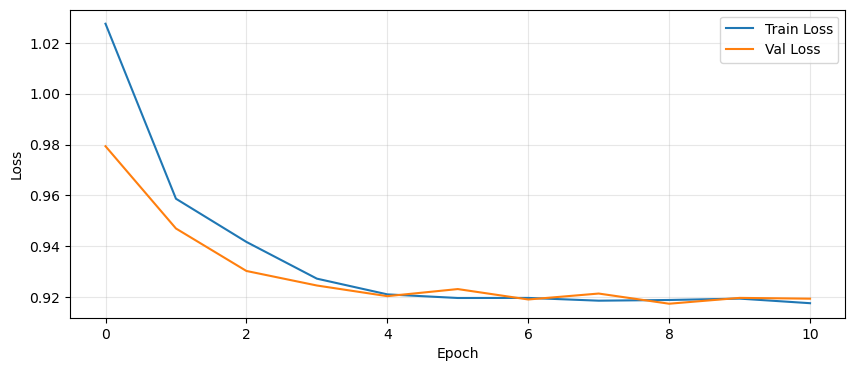

In [20]:
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()